1. Imports + device

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
from torch.utils.data import DataLoader, random_split

from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import json
import random

In [2]:
# Reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

os.makedirs("./models", exist_ok=True)
os.makedirs("./results", exist_ok=True)

Using device: cuda


2. Correct datasets and transforms for ConvNeXt

Pre-trained ConvNeXt expects normalization from ImageNet.

In [15]:
weights = ConvNeXt_Tiny_Weights.DEFAULT

preprocess = weights.transforms()

train_transform = transforms.Compose([
    transforms.Resize((256, 256)), # Updated from 224 to 256 according to Exp2
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((256, 256)),  # Updated from 224 to 256 according to Exp2
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

3. Load Oxford-IIIT Pet

In [16]:
full_train_dataset = datasets.OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="category",
    transform=train_transform,
    download=True
)

test_dataset = datasets.OxfordIIITPet(
    root="./data",
    split="test",
    target_types="category",
    transform=eval_transform,
    download=True
)

class_names = full_train_dataset.classes
num_classes = len(class_names)

print("Number of classes:", num_classes)
print("Training + validation images:", len(full_train_dataset))
print("Test images:", len(test_dataset))

Number of classes: 37
Training + validation images: 3680
Test images: 3669


4. Train/validation Split

In [17]:
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(seed)
)

train_indices = train_dataset.indices
val_indices = val_dataset.indices

full_eval_dataset = datasets.OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="category",
    transform=eval_transform,
    download=True
)

val_dataset.dataset = full_eval_dataset

5. DataLoaders

In [18]:
batch_size = 24 # Updated from 32 to 24 according to Exp2

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

6. Create ConvNeXt Model

Version 1 - Feature Extractor

This is the safest way to start.

In [19]:
model = convnext_tiny(weights=weights)

for param in model.parameters():
    param.requires_grad = False

in_features = model.classifier[2].in_features
#model.classifier[2] = nn.Linear(in_features, num_classes)

model.classifier = nn.Sequential(
    model.classifier[0],
    model.classifier[1],
    nn.Dropout(0.1),
    nn.Linear(in_features, num_classes)
)

for param in model.features[-1].parameters():

    param.requires_grad = True

for param in model.classifier.parameters():

    param.requires_grad = True

model = model.to(device)

print(model.classifier)

Sequential(
  (0): LayerNorm2d((768,), eps=1e-06, elementwise_affine=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Dropout(p=0.1, inplace=False)
  (3): Linear(in_features=768, out_features=37, bias=True)
)


7. Loss, optimizer and scheduler

In [20]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.00005,
    weight_decay=0.0001
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=3,
    factor=0.5
)

8. Training Function

In [21]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

9. Validation Function

In [22]:
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

10. Training Loop

In [23]:
num_epochs = 15

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "lr": []
}

best_val_acc = 0.0
best_model_path = "./models/convnext_tiny_best.pth"

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["lr"].append(current_lr)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"LR: {current_lr:.6f}"
    )

print(f"Best Validation Accuracy: {best_val_acc:.4f}")

Epoch [1/15] Train Loss: 2.9935 | Train Acc: 0.4022 | Val Loss: 1.9650 | Val Acc: 0.8315 | LR: 0.000050
Epoch [2/15] Train Loss: 1.2260 | Train Acc: 0.8865 | Val Loss: 0.5640 | Val Acc: 0.9280 | LR: 0.000050
Epoch [3/15] Train Loss: 0.5049 | Train Acc: 0.9365 | Val Loss: 0.2911 | Val Acc: 0.9416 | LR: 0.000050
Epoch [4/15] Train Loss: 0.3230 | Train Acc: 0.9524 | Val Loss: 0.2241 | Val Acc: 0.9402 | LR: 0.000050
Epoch [5/15] Train Loss: 0.2320 | Train Acc: 0.9698 | Val Loss: 0.1857 | Val Acc: 0.9457 | LR: 0.000050
Epoch [6/15] Train Loss: 0.1710 | Train Acc: 0.9803 | Val Loss: 0.1594 | Val Acc: 0.9497 | LR: 0.000050
Epoch [7/15] Train Loss: 0.1293 | Train Acc: 0.9861 | Val Loss: 0.1478 | Val Acc: 0.9538 | LR: 0.000050
Epoch [8/15] Train Loss: 0.1030 | Train Acc: 0.9901 | Val Loss: 0.1372 | Val Acc: 0.9511 | LR: 0.000050
Epoch [9/15] Train Loss: 0.0830 | Train Acc: 0.9922 | Val Loss: 0.1309 | Val Acc: 0.9538 | LR: 0.000050
Epoch [10/15] Train Loss: 0.0797 | Train Acc: 0.9935 | Val Loss:

***SKIPPED TO STEP 16 FOR EXPERIMENTS BEFORE RUNNING THE REST OF IT.***

11. Loss and Accuracy

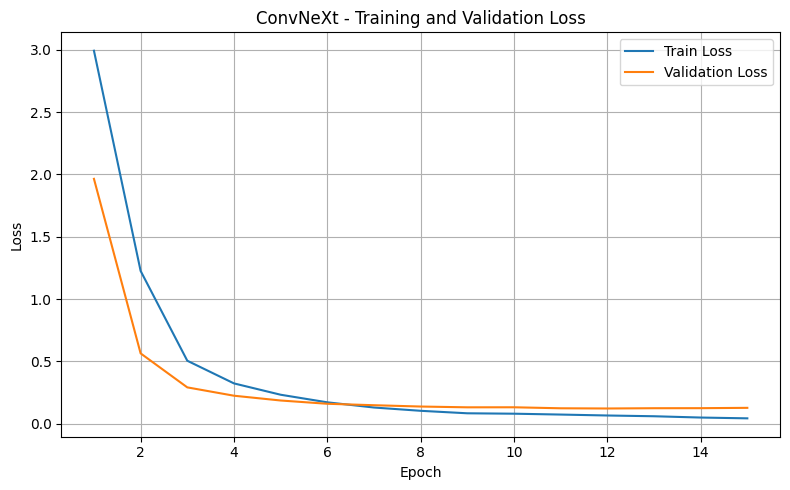

In [24]:
epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Validation Loss")
plt.title("ConvNeXt - Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("./results/convnext_loss_curve.png", dpi=150)
plt.show()

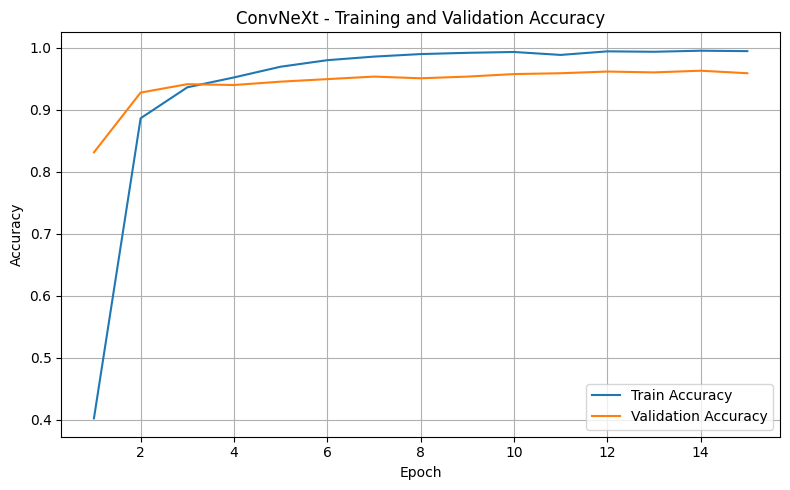

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_acc"], label="Train Accuracy")
plt.plot(epochs_range, history["val_acc"], label="Validation Accuracy")
plt.title("ConvNeXt - Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("./results/convnext_accuracy_curve.png", dpi=150)
plt.show()

12. Evaluation

In [26]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.to(device)
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [27]:
test_acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Macro Precision: {precision:.4f}")
print(f"Macro Recall: {recall:.4f}")

Test Accuracy: 0.9370
Macro Precision: 0.9387
Macro Recall: 0.9368


13. Classification report

In [28]:
print(classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    zero_division=0
))

                            precision    recall  f1-score   support

                Abyssinian       0.92      0.92      0.92        98
          American Bulldog       0.85      0.94      0.89       100
 American Pit Bull Terrier       0.78      0.62      0.69       100
              Basset Hound       0.98      0.93      0.95       100
                    Beagle       0.92      0.97      0.95       100
                    Bengal       0.75      0.99      0.85       100
                    Birman       0.83      0.86      0.85       100
                    Bombay       0.83      0.98      0.90        88
                     Boxer       0.95      0.93      0.94        99
         British Shorthair       0.95      0.82      0.88       100
                 Chihuahua       0.96      0.97      0.97       100
              Egyptian Mau       0.96      0.88      0.91        97
    English Cocker Spaniel       0.99      0.97      0.98       100
            English Setter       0.99      1.00

14. Confusion Matrix

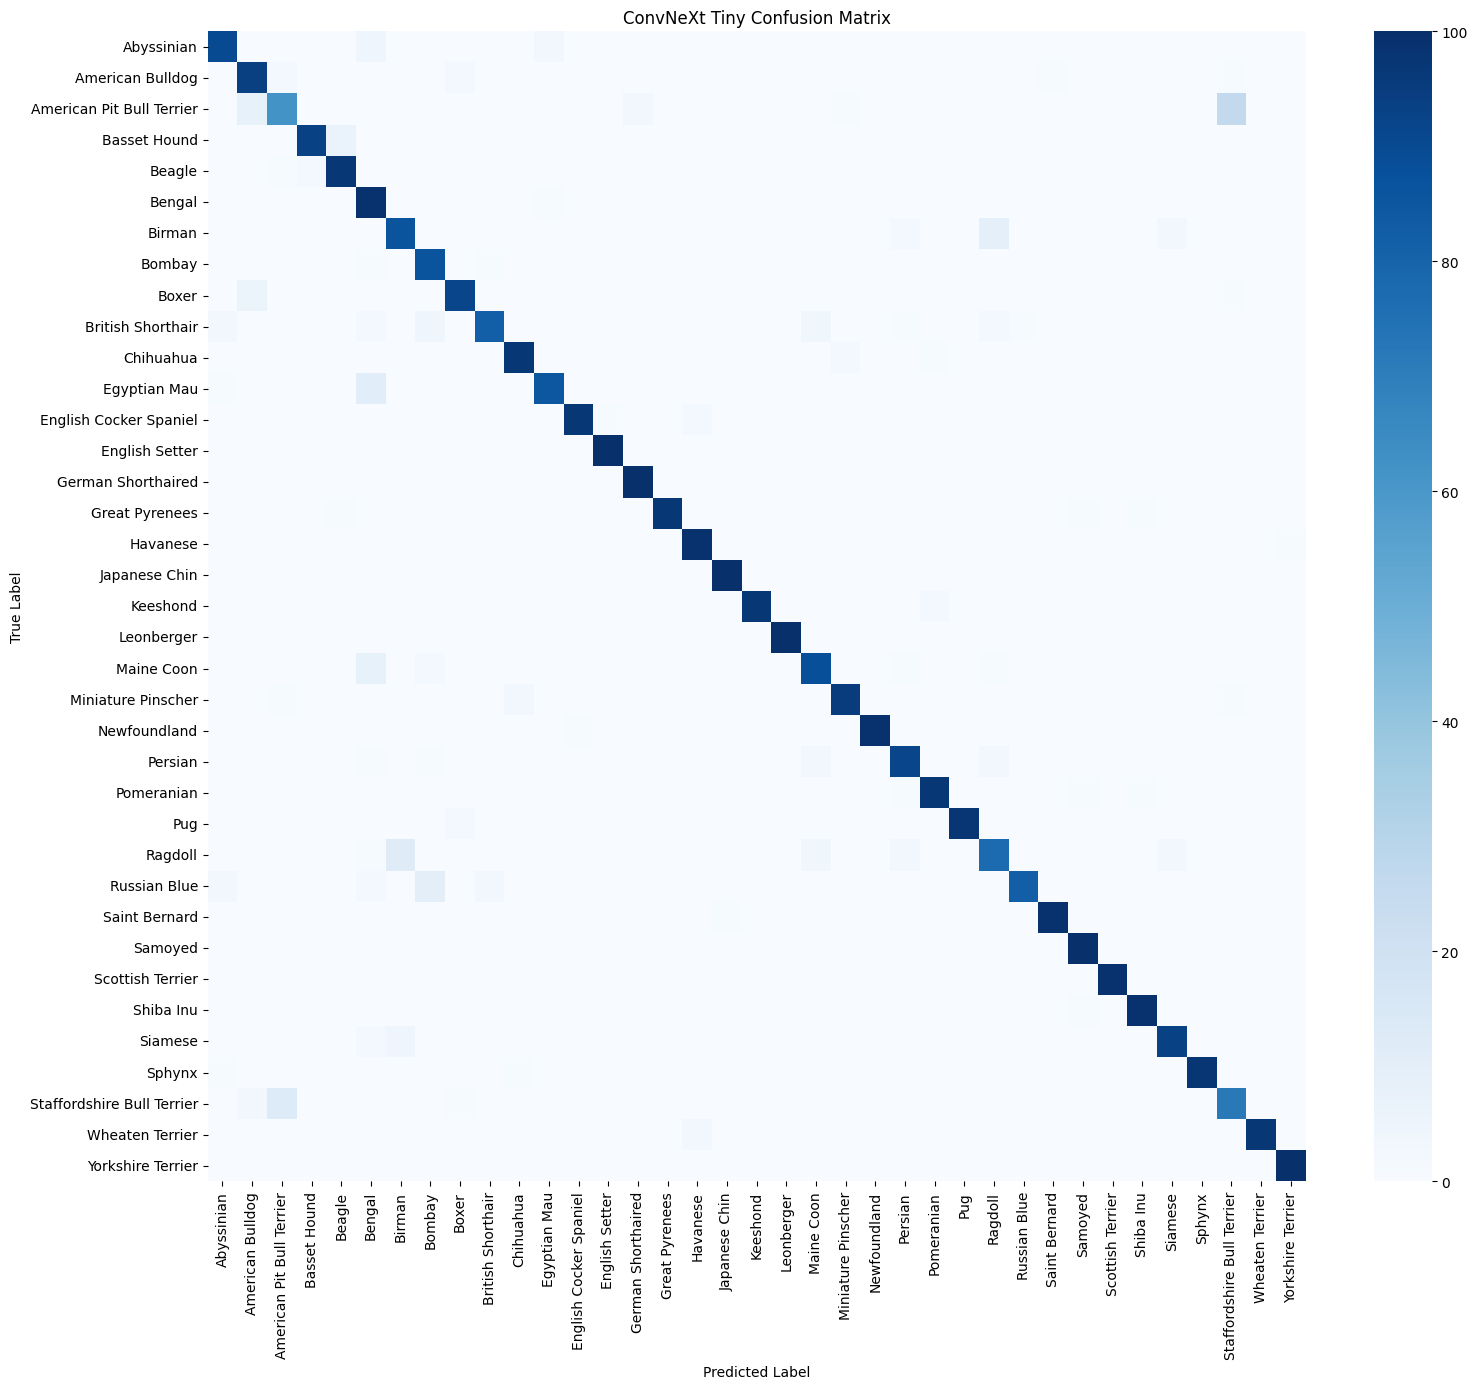

In [29]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(16, 14))

sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("ConvNeXt Tiny Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("./results/convnext_confusion_matrix.png", dpi=150)
plt.show()

15. Save Results

In [30]:
results = {
    "model": "ConvNeXt Tiny",
    "pretrained": True,
    "training_strategy": "last_block", #updated from feature_extractor
    "image_size": 256, #updated from 224
    "batch_size": batch_size,
    "optimizer": "AdamW",
    "learning_rate": 0.001,
    "weight_decay": 1e-4,
    "dropout": 0.1, #added for Exp2
    "augmentation": "baseline", #added for Exp2
    "epochs_trained": len(history["train_loss"]),
    "best_validation_accuracy": float(best_val_acc),
    "test_accuracy": float(test_acc),
    "macro_precision": float(precision),
    "macro_recall": float(recall)
}

with open("./results/convnext_tiny_results.json", "w") as f:
    json.dump(results, f, indent=4)

print(json.dumps(results, indent=4))

{
    "model": "ConvNeXt Tiny",
    "pretrained": true,
    "training_strategy": "last_block",
    "image_size": 256,
    "batch_size": 24,
    "optimizer": "AdamW",
    "learning_rate": 0.001,
    "weight_decay": 0.0001,
    "dropout": 0.1,
    "augmentation": "baseline",
    "epochs_trained": 15,
    "best_validation_accuracy": 0.9633152173913043,
    "test_accuracy": 0.9370400654129191,
    "macro_precision": 0.9386881557471473,
    "macro_recall": 0.9367569839767884
}


16. Hyperparameter Experiments

The baseline ConvNeXt Tiny model achieved a best validation accuracy of 0.9606 and a test accuracy of 0.9343, which already demonstrates strong classification performance on the Oxford-IIIT Pets dataset. However, additional hyperparameter experiments were conducted to investigate whether better generalization and robustness could be achieved through controlled fine-tuning strategies and optimization adjustments.


In [12]:
# ============================================================
# EXP-0: Helper — full ConvNeXt Tiny training function
# ============================================================

from torch.utils.data import DataLoader, Subset
from sklearn.metrics import precision_score, recall_score

EPOCHS_EXP = 30
IMG_SIZE_EXP = 224

def make_convnext_loaders(batch_size, aug="baseline", image_size=224):
    """Create train/val/test loaders for ConvNeXt experiments."""

    if aug == "strong":
        tr = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.2),
            transforms.RandomRotation(30),
            transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4),
            transforms.RandomGrayscale(p=0.1),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],
                                 [0.229, 0.224, 0.225]),
            transforms.RandomErasing(p=0.25)
        ])

    elif aug == "none":
        tr = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],
                                 [0.229, 0.224, 0.225])
        ])

    else:
        tr = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],
                                 [0.229, 0.224, 0.225])
        ])

    ev = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    tr_ds = datasets.OxfordIIITPet(
        root="./data",
        split="trainval",
        target_types="category",
        transform=tr,
        download=False
    )

    ev_ds = datasets.OxfordIIITPet(
        root="./data",
        split="trainval",
        target_types="category",
        transform=ev,
        download=False
    )

    te_ds = datasets.OxfordIIITPet(
        root="./data",
        split="test",
        target_types="category",
        transform=ev,
        download=False
    )

    tr_ds = Subset(tr_ds, train_indices)
    ev_ds = Subset(ev_ds, val_indices)

    trl = DataLoader(tr_ds, batch_size=batch_size, shuffle=True,
                     num_workers=2, pin_memory=True)

    vl = DataLoader(ev_ds, batch_size=batch_size, shuffle=False,
                    num_workers=2, pin_memory=True)

    tel = DataLoader(te_ds, batch_size=batch_size, shuffle=False,
                     num_workers=2, pin_memory=True)

    return trl, vl, tel


def build_convnext(strategy="last_block", dropout=0.0):
    """Build ConvNeXt Tiny and apply the chosen fine-tuning strategy."""

    weights = ConvNeXt_Tiny_Weights.DEFAULT
    m = convnext_tiny(weights=weights)

    for param in m.parameters():
        param.requires_grad = False

    in_features = m.classifier[2].in_features

    m.classifier = nn.Sequential(
        m.classifier[0],
        m.classifier[1],
        nn.Dropout(dropout),
        nn.Linear(in_features, num_classes)
    )

    if strategy == "classifier_only":
        for param in m.classifier.parameters():
            param.requires_grad = True

    elif strategy == "last_block":
        for param in m.features[-1].parameters():
            param.requires_grad = True
        for param in m.classifier.parameters():
            param.requires_grad = True

    elif strategy == "last_two_blocks":
        for param in m.features[-2:].parameters():
            param.requires_grad = True
        for param in m.classifier.parameters():
            param.requires_grad = True

    elif strategy == "full_finetune":
        for param in m.parameters():
            param.requires_grad = True

    else:
        raise ValueError("strategy must be: classifier_only, last_block, last_two_blocks, full_finetune")

    return m.to(device)


def run_convnext_experiment(
    name,
    lr,
    batch_size,
    dropout,
    aug,
    strategy="last_block",
    optimizer_type="adamw",
    wd=1e-4,
    image_size=224,
    epochs=EPOCHS_EXP,
    label_smoothing=0.05,
    scheduler_type="cosine"
):
    """Train ConvNeXt Tiny with given hyperparameters and return result dict."""

    print(f"\n{'='*70}")
    print(f"  EXP: {name}")
    print(f"  strategy={strategy} | lr={lr} | batch={batch_size} | dropout={dropout}")
    print(f"  aug={aug} | opt={optimizer_type} | wd={wd} | image_size={image_size}")
    print(f"{'='*70}")

    m = build_convnext(strategy=strategy, dropout=dropout)

    trl, vl, tel = make_convnext_loaders(
        batch_size=batch_size,
        aug=aug,
        image_size=image_size
    )

    trainable_params = [p for p in m.parameters() if p.requires_grad]

    if optimizer_type == "sgd":
        opt = optim.SGD(trainable_params, lr=lr, momentum=0.9, weight_decay=wd)
    elif optimizer_type == "adam":
        opt = optim.Adam(trainable_params, lr=lr, weight_decay=wd)
    else:
        opt = optim.AdamW(trainable_params, lr=lr, weight_decay=wd)

    crit = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

    if scheduler_type == "cosine":
        sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    elif scheduler_type == "plateau":
        sched = optim.lr_scheduler.ReduceLROnPlateau(
            opt, mode="min", factor=0.3, patience=3
        )
    else:
        sched = None

    best_val = 0.0
    best_path = f"./models/{name}_best.pth"

    for epoch in range(epochs):
        tr_loss, tr_acc = train_one_epoch(m, trl, crit, opt, device)
        vl_loss, vl_acc = evaluate(m, vl, crit, device)

        if scheduler_type == "plateau":
            sched.step(vl_loss)
        elif sched is not None:
            sched.step()

        if vl_acc > best_val:
            best_val = vl_acc
            torch.save(m.state_dict(), best_path)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(
                f"  Epoch {epoch+1}/{epochs} | "
                f"train_acc={tr_acc:.4f} | "
                f"val_acc={vl_acc:.4f} | "
                f"best={best_val:.4f}"
            )

    m.load_state_dict(torch.load(best_path, map_location=device))

    _, test_acc = evaluate(m, tel, crit, device)

    all_preds = []
    all_labels = []

    m.eval()
    with torch.no_grad():
        for images, labels in tel:
            images = images.to(device)
            labels = labels.to(device)

            outputs = m(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)

    print(f"  >>> FINAL best_val={best_val:.4f} | test_acc={test_acc:.4f}")

    return {
        "name": name,
        "model": "ConvNeXt Tiny",
        "pretrained": True,
        "strategy": strategy,
        "image_size": image_size,
        "lr": lr,
        "batch_size": batch_size,
        "dropout": dropout,
        "augmentation": aug,
        "optimizer": optimizer_type,
        "weight_decay": wd,
        "epochs": epochs,
        "label_smoothing": label_smoothing,
        "scheduler": scheduler_type,
        "best_val_acc": round(best_val, 4),
        "test_acc": round(test_acc, 4),
        "macro_precision": round(precision, 4),
        "macro_recall": round(recall, 4)
    }


exp_results = []
print("ConvNeXt experiment helpers ready.")

ConvNeXt experiment helpers ready.


In [13]:
# ============================================================
# EXP-1 to EXP-5: ConvNeXt Tiny experiments
# ============================================================

exp_results.append(run_convnext_experiment(
    name="exp1_convnext_lr_5e4",
    lr=5e-4,
    batch_size=32,
    dropout=0.1,
    aug="baseline",
    strategy="last_block",
    optimizer_type="adamw",
    wd=1e-4,
    epochs=20
))

exp_results.append(run_convnext_experiment(
    name="exp2_convnext_img256",
    lr=5e-4,
    batch_size=24,
    dropout=0.1,
    aug="baseline",
    strategy="last_block",
    optimizer_type="adamw",
    wd=1e-4,
    image_size=256,
    epochs=20
))

exp_results.append(run_convnext_experiment(
    name="exp3_convnext_classifier_only",
    lr=1e-3,
    batch_size=32,
    dropout=0.2,
    aug="strong",
    strategy="classifier_only",
    optimizer_type="adamw",
    wd=1e-4,
    epochs=20
))

exp_results.append(run_convnext_experiment(
    name="exp4_convnext_last_two_blocks",
    lr=5e-5,
    batch_size=16,
    dropout=0.2,
    aug="baseline",
    strategy="last_two_blocks",
    optimizer_type="adamw",
    wd=1e-3,
    epochs=30
))

exp_results.append(run_convnext_experiment(
    name="exp5_convnext_full_finetune",
    lr=1e-5,
    batch_size=16,
    dropout=0.2,
    aug="strong",
    strategy="full_finetune",
    optimizer_type="adamw",
    wd=1e-3,
    epochs=30
))


  EXP: exp1_convnext_lr_5e4
  strategy=last_block | lr=0.0005 | batch=32 | dropout=0.1
  aug=baseline | opt=adamw | wd=0.0001 | image_size=224
  Epoch 1/20 | train_acc=0.7989 | val_acc=0.9212 | best=0.9212
  Epoch 5/20 | train_acc=0.9912 | val_acc=0.9484 | best=0.9579
  Epoch 10/20 | train_acc=0.9969 | val_acc=0.9565 | best=0.9606
  Epoch 15/20 | train_acc=0.9997 | val_acc=0.9579 | best=0.9606
  Epoch 20/20 | train_acc=0.9983 | val_acc=0.9633 | best=0.9633
  >>> FINAL best_val=0.9633 | test_acc=0.9330

  EXP: exp2_convnext_img256
  strategy=last_block | lr=0.0005 | batch=24 | dropout=0.1
  aug=baseline | opt=adamw | wd=0.0001 | image_size=256
  Epoch 1/20 | train_acc=0.8010 | val_acc=0.9253 | best=0.9253
  Epoch 5/20 | train_acc=0.9851 | val_acc=0.9538 | best=0.9538
  Epoch 10/20 | train_acc=0.9946 | val_acc=0.9633 | best=0.9633
  Epoch 15/20 | train_acc=0.9986 | val_acc=0.9674 | best=0.9674
  Epoch 20/20 | train_acc=0.9993 | val_acc=0.9674 | best=0.9688
  >>> FINAL best_val=0.9688 | 

- Observations

Among all experiments, Experiment 2 (exp2_convnext_img256) produced the best overall performance with a validation accuracy of 96.88% and a test accuracy of 94.06%. This configuration used the last block fine-tuning strategy, a learning rate of 5×10⁻⁴, batch size 24, and a larger input resolution of 256×256. The improvement suggests that increasing image resolution allowed the model to capture more discriminative visual details while still maintaining stable optimization.

Although Experiment 4 achieved competitive results (96.60% validation, 93.87% test accuracy), full fine-tuning and classifier-only strategies performed worse, indicating that selectively fine-tuning deeper layers is more effective than either freezing most layers or updating the entire network.

In [14]:
# ============================================================
# FINAL RESULTS TABLE
# ============================================================

import pandas as pd

df_exp = pd.DataFrame(exp_results)
df_exp = df_exp.sort_values(by="test_acc", ascending=False)

display(df_exp)

df_exp.to_csv("./results/convnext_experiment_results.csv", index=False)
print("Saved to ./results/convnext_experiment_results.csv")

,name,model,pretrained,strategy,image_size,lr,batch_size,dropout,augmentation,optimizer,weight_decay,epochs,label_smoothing,scheduler,best_val_acc,test_acc,macro_precision,macro_recall
1,exp2_convnext_img256,ConvNeXt Tiny,True,last_block,256,0.00050,24,0.1,baseline,adamw,0.0001,20,0.05,cosine,0.9688,0.9406,0.9418,0.9400
3,exp4_convnext_last_two_blocks,ConvNeXt Tiny,True,last_two_blocks,224,0.00005,16,0.2,baseline,adamw,0.0010,30,0.05,cosine,0.9660,0.9387,0.9392,0.9383
0,exp1_convnext_lr_5e4,ConvNeXt Tiny,True,last_block,224,0.00050,32,0.1,baseline,adamw,0.0001,20,0.05,cosine,0.9633,0.9330,0.9345,0.9325
2,exp3_convnext_classifier_only,ConvNeXt Tiny,True,classifier_only,224,0.00100,32,0.2,strong,adamw,0.0001,20,0.05,cosine,0.9552,0.9248,0.9283,0.9245
4,exp5_convnext_full_finetune,ConvNeXt Tiny,True,full_finetune,224,0.00001,16,0.2,strong,adamw,0.0010,30,0.05,cosine,0.9538,0.9237,0.9271,0.9236


Saved to ./results/convnext_experiment_results.csv


***Update according to Best Results (Exp2) and run again till STEP 16.***